In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from underthesea import word_tokenize
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [36]:
# =========================
# LOAD DATA
# =========================
data_path = "../data/processed/"

train_df = pd.read_excel(os.path.join(data_path, "train.xlsx"))
dev_df   = pd.read_excel(os.path.join(data_path, "dev.xlsx"))
test_df  = pd.read_excel(os.path.join(data_path, "test.xlsx"))

X_train_raw = train_df["clean_review"]
y_train = train_df["label"]

X_dev_raw = dev_df["clean_review"]
y_dev = dev_df["label"]

X_test_raw = test_df["clean_review"]
y_test = test_df["label"]

print("Train size:", len(X_train_raw))
print("Dev size:", len(X_dev_raw))
print("Test size:", len(X_test_raw))

Train size: 20591
Dev size: 4417
Test size: 4431


In [37]:
# =========================
# LOAD STOPWORDS
# =========================
stopwords_path = os.path.join("..", "dicts", "vietnamese-stopwords.txt")

with open(stopwords_path, "r", encoding="utf-8") as f:
    stopwords = set([line.strip() for line in f])

print("Number of stopwords:", len(stopwords))

Number of stopwords: 1942


In [38]:
# =========================
# PREPROCESS FUNCTION
# =========================
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Tách từ (underthesea)
    text = word_tokenize(text, format="text")
    
    # 2. Xóa stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords]
    
    return " ".join(tokens)

In [39]:
# =========================
# APPLY PREPROCESSING
# =========================
X_train = X_train_raw.apply(preprocess_text)
X_dev   = X_dev_raw.apply(preprocess_text)
X_test  = X_test_raw.apply(preprocess_text)

# Xem thử kết quả
print("Before:", X_train_raw.iloc[0])
print("After :", X_train.iloc[0])

Before: hơi kém màu đúng
After : hơi kém màu


In [40]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    norm='l2'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_dev_tfidf   = vectorizer.transform(X_dev)
X_test_tfidf  = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (20591, 20000)


In [41]:
# =========================
# NAIVE BAYES
# =========================
nb_params = {"alpha": [0.01, 0.1, 0.5, 1.0]}

nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

nb_grid.fit(X_train_tfidf, y_train)
nb_best = nb_grid.best_estimator_

print("Best NB params:", nb_grid.best_params_)

Best NB params: {'alpha': 0.1}


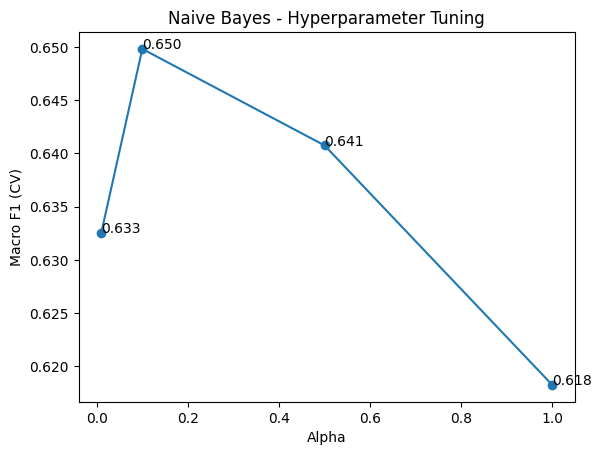

In [42]:
# =========================
# VISUALIZE NB
# =========================
import matplotlib.pyplot as plt

alphas = nb_grid.cv_results_['param_alpha'].data
scores = nb_grid.cv_results_['mean_test_score']

plt.figure()
plt.plot(alphas, scores, marker='o')

plt.xlabel("Alpha")
plt.ylabel("Macro F1 (CV)")
plt.title("Naive Bayes - Hyperparameter Tuning")

for i in range(len(alphas)):
    plt.text(alphas[i], scores[i], f"{scores[i]:.3f}")

plt.show()

In [43]:

# =========================
# SVM
# =========================
svm_params = {"C": [0.1, 1, 10]}

svm_grid = GridSearchCV(
    LinearSVC(),
    svm_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)
svm_best = svm_grid.best_estimator_

print("Best SVM params:", svm_grid.best_params_)


Best SVM params: {'C': 1}


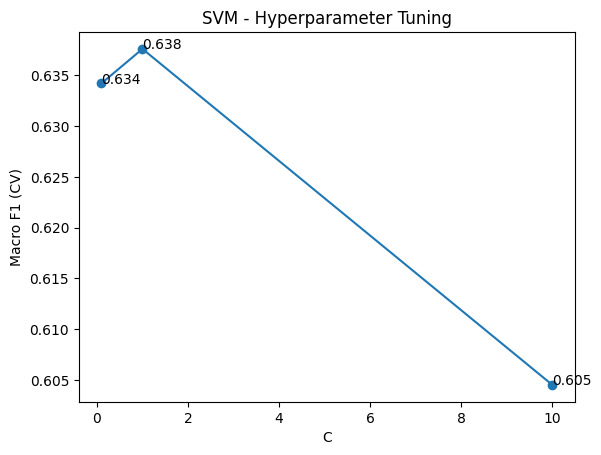

In [44]:
# =========================
# VISUALIZE SVM
# =========================
C_values = svm_grid.cv_results_['param_C'].data
scores = svm_grid.cv_results_['mean_test_score']

plt.figure()
plt.plot(C_values, scores, marker='o')

plt.xlabel("C")
plt.ylabel("Macro F1 (CV)")
plt.title("SVM - Hyperparameter Tuning")

for i in range(len(C_values)):
    plt.text(C_values[i], scores[i], f"{scores[i]:.3f}")

plt.show()

In [45]:
# =========================
# RANDOM FOREST
# =========================
rf_params = {
    "n_estimators": [20, 50, 100, 200],
    "max_depth": [None, 10, 20]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train_tfidf, y_train)
rf_best = rf_grid.best_estimator_

print("Best RF params:", rf_grid.best_params_)

Best RF params: {'max_depth': None, 'n_estimators': 100}


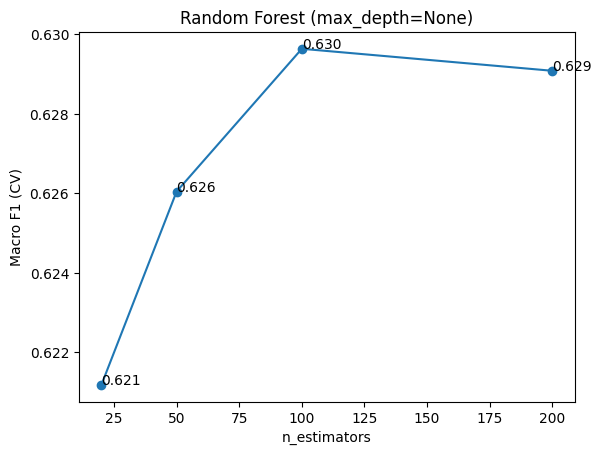

In [46]:
# =========================
# VISUALIZE RANDOM FOREST 
# =========================
results = pd.DataFrame(rf_grid.cv_results_)

# lọc max_depth = None (thực chất là NaN)
filtered = results[results['param_max_depth'].isna()]

# convert kiểu dữ liệu
n_estimators = filtered['param_n_estimators'].astype(int)
scores = filtered['mean_test_score']

plt.figure()
plt.plot(n_estimators, scores, marker='o')

plt.xlabel("n_estimators")
plt.ylabel("Macro F1 (CV)")
plt.title("Random Forest (max_depth=None)")

for i in range(len(n_estimators)):
    plt.text(n_estimators.iloc[i], scores.iloc[i], f"{scores.iloc[i]:.3f}")

plt.show()

In [47]:
# =========================
# PROFESSIONAL EVALUATION FUNCTION
# =========================
def evaluate(model, X, y, name="Model"):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    f1  = f1_score(y, y_pred, average="macro")

    # Title đẹp
    display(Markdown(f"## {name} Evaluation"))

    # ===== Summary Table =====
    summary_df = pd.DataFrame({
        "Metric": ["Accuracy", "Macro F1"],
        "Score": [round(acc, 4), round(f1, 4)]
    })

    display(summary_df.style.set_caption("Overall Performance"))

    # ===== Classification Report =====
    report = classification_report(y, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    display(report_df.style
            .set_caption("Classification Report")
            .format("{:.4f}"))

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y, y_pred)

    labels = sorted(list(set(y)))  # hoặc tự set: ["Negative","Neutral","Positive"]

    plt.figure()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

## Naive Bayes (Dev) Evaluation

,Metric,Score
0,Accuracy,0.684200
1,Macro F1,0.652000


,precision,recall,f1-score,support
0,0.6960,0.7185,0.7071,1542.0000
1,0.5200,0.4203,0.4649,1111.0000
2,0.7509,0.8203,0.7841,1764.0000
accuracy,0.6842,0.6842,0.6842,0.6842
macro avg,0.6556,0.6531,0.6520,4417.0000
weighted avg,0.6737,0.6842,0.6769,4417.0000


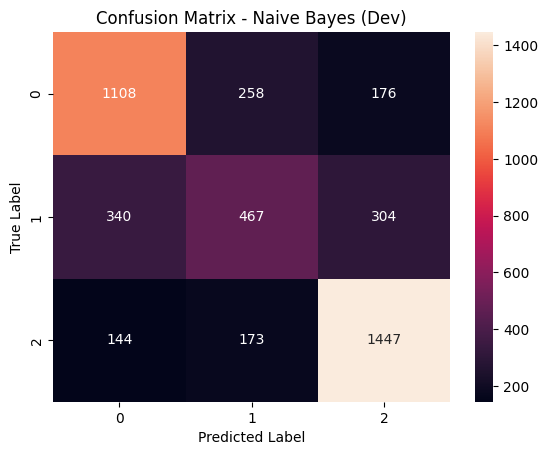

In [48]:
# =========================
# EVALUATE ON DEV
# =========================
evaluate(nb_best, X_dev_tfidf, y_dev, "Naive Bayes (Dev)")

## SVM (Dev) Evaluation

,Metric,Score
0,Accuracy,0.670400
1,Macro F1,0.635500


,precision,recall,f1-score,support
0,0.6809,0.7348,0.7068,1542.0000
1,0.4847,0.3852,0.4293,1111.0000
2,0.7487,0.7937,0.7705,1764.0000
accuracy,0.6704,0.6704,0.6704,0.6704
macro avg,0.6381,0.6379,0.6355,4417.0000
weighted avg,0.6586,0.6704,0.6624,4417.0000


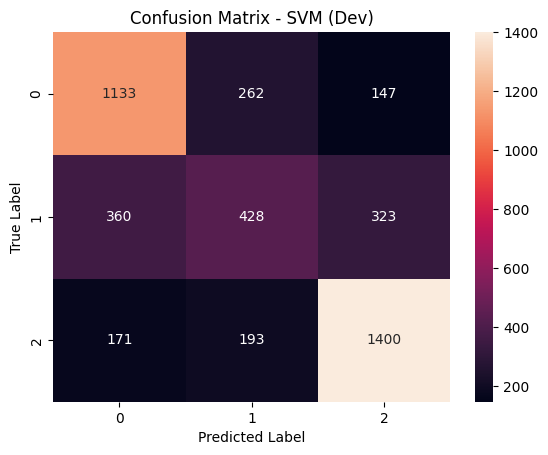

In [49]:
evaluate(svm_best, X_dev_tfidf, y_dev, "SVM (Dev)")

## Random Forest (Dev) Evaluation

,Metric,Score
0,Accuracy,0.695500
1,Macro F1,0.649900


,precision,recall,f1-score,support
0,0.6852,0.7905,0.7341,1542.0000
1,0.6094,0.3384,0.4352,1111.0000
2,0.7308,0.8373,0.7804,1764.0000
accuracy,0.6955,0.6955,0.6955,0.6955
macro avg,0.6751,0.6554,0.6499,4417.0000
weighted avg,0.6844,0.6955,0.6774,4417.0000


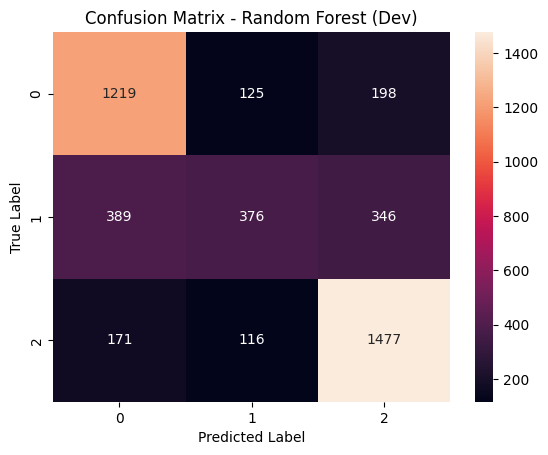

In [50]:
evaluate(rf_best, X_dev_tfidf, y_dev, "Random Forest (Dev)")

## Naive Bayes (Test) Evaluation

,Metric,Score
0,Accuracy,0.700700
1,Macro F1,0.666400


,precision,recall,f1-score,support
0,0.7189,0.7534,0.7357,1541.0000
1,0.5465,0.4169,0.4730,1113.0000
2,0.7524,0.8329,0.7906,1777.0000
accuracy,0.7007,0.7007,0.7007,0.7007
macro avg,0.6726,0.6677,0.6664,4431.0000
weighted avg,0.6890,0.7007,0.6917,4431.0000


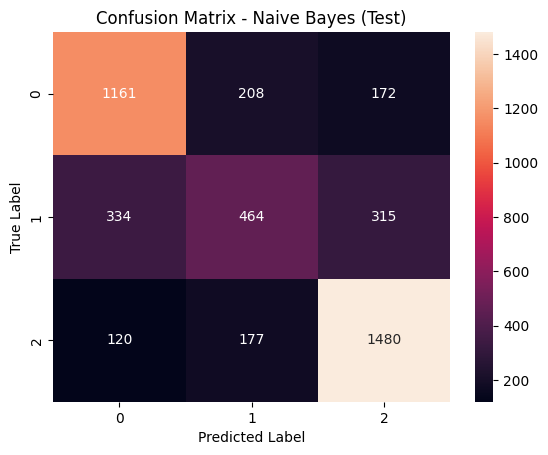

In [51]:
# =========================
# EVALUATE ON TEST
# =========================
evaluate(nb_best, X_test_tfidf, y_test, "Naive Bayes (Test)")

## SVM (Test) Evaluation

,Metric,Score
0,Accuracy,0.692800
1,Macro F1,0.659200


,precision,recall,f1-score,support
0,0.6941,0.7670,0.7287,1541.0000
1,0.5453,0.4106,0.4685,1113.0000
2,0.7571,0.8053,0.7805,1777.0000
accuracy,0.6928,0.6928,0.6928,0.6928
macro avg,0.6655,0.6610,0.6592,4431.0000
weighted avg,0.6820,0.6928,0.6841,4431.0000


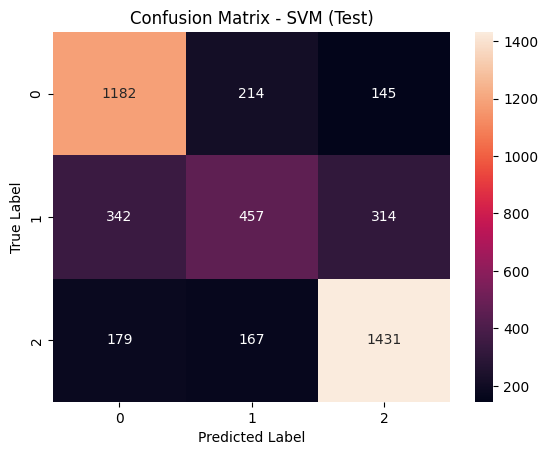

In [52]:
evaluate(svm_best, X_test_tfidf, y_test, "SVM (Test)")

## Random Forest (Test) Evaluation

,Metric,Score
0,Accuracy,0.698300
1,Macro F1,0.652600


,precision,recall,f1-score,support
0,0.6910,0.7936,0.7387,1541.0000
1,0.6258,0.3396,0.4403,1113.0000
2,0.7258,0.8402,0.7788,1777.0000
accuracy,0.6983,0.6983,0.6983,0.6983
macro avg,0.6809,0.6578,0.6526,4431.0000
weighted avg,0.6886,0.6983,0.6799,4431.0000


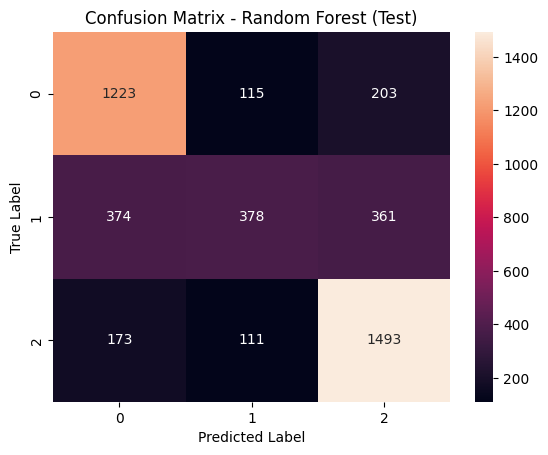

In [53]:
evaluate(rf_best, X_test_tfidf, y_test, "Random Forest (Test)")

In [54]:
# =========================
# COMPARISON TABLE
# =========================
results = []

models = {
    "Naive Bayes": nb_best,
    "SVM": svm_best,
    "Random Forest": rf_best
}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1, 4)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

results_df

,Model,Accuracy,Macro F1
0,Naive Bayes,0.7007,0.6664
1,SVM,0.6928,0.6592
2,Random Forest,0.6983,0.6526


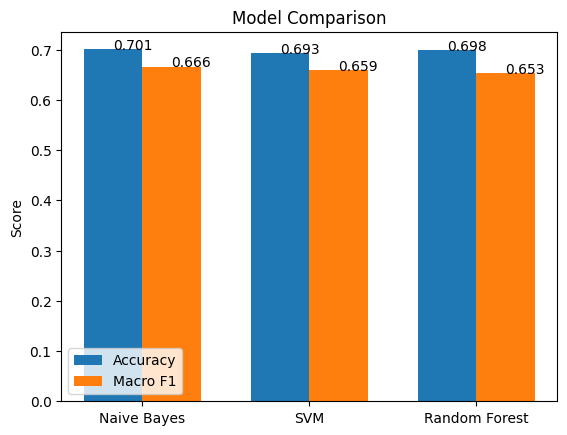

In [55]:
models = results_df["Model"]
accuracy = results_df["Accuracy"]
f1_scores = results_df["Macro F1"]

x = np.arange(len(models))
width = 0.35

plt.figure()

plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="Macro F1")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison")

# Hiển thị số
for i in range(len(models)):
    plt.text(x[i] - width/2, accuracy[i], f"{accuracy[i]:.3f}")
    plt.text(x[i] + width/2, f1_scores[i], f"{f1_scores[i]:.3f}")

plt.legend()
plt.show()

In [ ]:
# =========================
# SAVE RESULTS
# =========================
results_df.to_excel("model_comparison.xlsx", index=False)